<a href="https://colab.research.google.com/github/FrancisQL/Computer_Vision/blob/main/Notebooks/AL05-FeatureMatching/AL5_Feature_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AL5 — Feature Matching: FLANN, the Ratio Test, and Finding a Photo
**MCS 3950 Computer Vision · UPEI · Fall 2026 · Friday Oct 9**

L7 ended with brute-force matching and Lowe's ratio test on a pair we had built
ourselves. Today we make matching **fast** (FLANN), **look at it** on a real pair of
photographs, and then use it for a job the coastal project groups face: given a
piece of the 1958 map, **which of twenty raw air photos shows it?**

| Part | Topic | Time |
|------|-------|------|
| 1 | Brute force vs FLANN, on the L7 pair with a known answer | ~15 min |
| 2 | A real pair: two consecutive 1958 air photos | ~15 min |
| 3 | Which photo is this? Searching twenty frames at once | ~20 min |
| ★ | Bonus: does the query's resolution matter? | if time |

Each part has a **task** you implement and **checkpoint questions** you answer in
the cells provided.

> **Not submitted or graded.** This is Test 2 material (L7–L11). After reading week,
> L8 turns today's matches into a homography with RANSAC, and AL6 stitches a panorama.

In [1]:
import io, os, time, urllib.request, zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
GOLD, RED, TEAL, GREEN, NAVY, GREY = "#C8962C", "#B82828", "#1A7A8A", "#2E7D50", "#1A3A5C", "#9AA5B1"

def show(images, titles, cmap='gray', vmin=0, vmax=255, figw=15, figh=4.5):
    # Show a row of images.
    fig, axes = plt.subplots(1, len(images), figsize=(figw, figh))
    if len(images) == 1:
        axes = [axes]
    for ax, im, t in zip(axes, images, titles):
        colour = im.ndim == 3
        ax.imshow(im, cmap=None if colour else cmap,
                  vmin=None if colour else vmin, vmax=None if colour else vmax)
        ax.set_title(t, fontsize=11); ax.axis('off')
    plt.tight_layout(); plt.show()

def project(pts, H):
    # Apply a 3x3 transform to an (N, 2) array of points.
    p = np.c_[pts, np.ones(len(pts))] @ H.T
    return p[:, :2] / p[:, 2:]

def ratio_test(knn, r=0.8):
    # Lowe's ratio test on the output of knnMatch(k=2): keep the best match of each
    # query if it is clearly better than the runner-up. Queries that came back with
    # fewer than two neighbours are skipped (FLANN's LSH index can do that).
    return [p[0] for p in knn if len(p) == 2 and p[0].distance < r * p[1].distance]

def best_of(f, repeats=3):
    # Run f() a few times; return (result, fastest time in seconds).
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter(); out = f(); best = min(best, time.perf_counter() - t0)
    return out, best

print(f"OpenCV {cv2.__version__}")

OpenCV 5.0.0


## Get the imagery

The three clips from AL2 (`AL2.zip`, ~3 MB, the same download as L5–L7), and twenty
raw 1958 air photos for Parts 2 and 3 (`AL5.zip`, ~8 MB). Safe to re-run.

In [2]:
BASE = ("https://raw.githubusercontent.com/andrewgodbout/"
        "MCS-3950-F26/main/Notebooks/data/")

def fetch_zip(name, needed):
    if all(os.path.exists(f) for f in needed):
        print(f"{name}: already present")
        return
    with urllib.request.urlopen(BASE + name, timeout=120) as r:
        blob = r.read()
    with zipfile.ZipFile(io.BytesIO(blob)) as z:
        z.extractall(".")
    print(f"{name}: {len(blob)/1e6:.1f} MB downloaded and extracted")

fetch_zip("AL2.zip", ["pei_1935.png", "pei_1958.png", "pei_1968.png"])
fetch_zip("AL5.zip", ["frames/16046-19.jpg", "frames/16046-20.jpg"])

NAMES = sorted(f[:-4] for f in os.listdir("frames") if f.endswith(".jpg"))
print(f"{len(NAMES)} frames: {', '.join(NAMES)}")

# The 1968 clip on the 1 m grid, exactly as in L7
RES = {1958: 1.1593543264609192, 1968: 0.5}
def to_grid(img, src_res, target=1.0):
    s = src_res / target
    wh = (int(round(img.shape[1]*s)), int(round(img.shape[0]*s)))
    return cv2.resize(img, wh, interpolation=cv2.INTER_AREA if s < 1 else cv2.INTER_CUBIC)

img = to_grid(cv2.imread("pei_1968.png", cv2.IMREAD_GRAYSCALE), RES[1968])[:800, :800]
h, w = img.shape

AL2.zip: 3.1 MB downloaded and extracted
AL5.zip: 7.6 MB downloaded and extracted
20 frames: 16011-130, 16046-101, 16046-102, 16046-103, 16046-104, 16046-105, 16046-17, 16046-18, 16046-19, 16046-20, 16046-21, 16046-22, 16094-11, 16096-114, 16097-9, 16100-72, 16108-3, 16108-94, 16110-53, 16114-70


---
## Part 1 — Brute Force vs FLANN  `⏱ ~15 min`

### The L7 test pair, again

Same pair as L7 §0: the 1968 clip, and a copy we rotated 30°, shrank to 0.7, re-exposed
(γ = 0.7) and sprinkled with grain. Because we made the warp, we know where every
keypoint should land: a match is **correct** if it lands within 3 px of that spot.

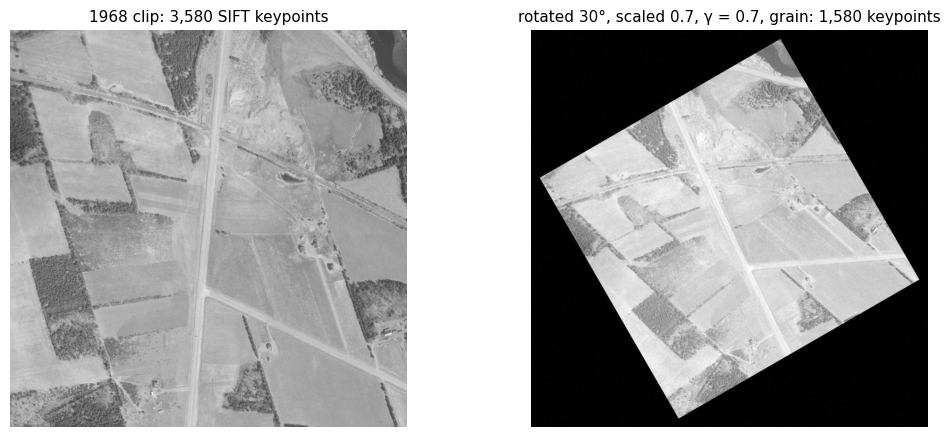

In [3]:
def make_pair(img, angle=30, scale=0.7, gain=1.1, gamma=0.7, noise=4, seed=0):
    # Rotate + scale about the centre, then a non-linear exposure change and grain.
    # Returns the new image, the 3x3 matrix H that maps img -> new, and a valid-pixel mask.
    A = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
    H = np.vstack([A, [0, 0, 1]])
    out = cv2.warpAffine(img, A, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)
    f = out.astype(np.float64) / 255
    rng = np.random.default_rng(seed)
    f = gain * f**gamma * 255 + rng.normal(0, noise, f.shape)
    mask = cv2.warpAffine(np.full_like(img, 255), A, (w, h))
    return np.clip(f, 0, 255).astype(np.uint8), H, mask

def is_correct(kp1, kp2, matches, H, tol=3):
    # Boolean per match: does kp2 sit where H says kp1 should have gone?
    p1 = project(np.float32([kp1[m.queryIdx].pt for m in matches]), H)
    p2 = np.float32([kp2[m.trainIdx].pt for m in matches])
    return np.linalg.norm(p1 - p2, axis=1) < tol

img2, H, mask2 = make_pair(img)
sift = cv2.SIFT_create()
k1, d1 = sift.detectAndCompute(img, None)
k2, d2 = sift.detectAndCompute(img2, mask2)
show([img, img2], [f"1968 clip: {len(k1):,} SIFT keypoints",
                   f"rotated 30°, scaled 0.7, γ = 0.7, grain: {len(k2):,} keypoints"], figw=11)

### Step 1 · The brute-force baseline (L7 §9)

Recall that SIFT computes a feature descriptor as a vector with 128 floating point dimensions for each feature descriptor in the reference (query) and target (train) image. For each of those descriptors we want to find the closest match between the 2 sets of descriptors. We can do this in a brute force approach:

`cv2.BFMatcher(cv2.NORM_L2).knnMatch(d1, d2, k=2)` computes the distance from **every**
query descriptor to **every** train descriptor, here $3{,}580 \times 1{,}573 \approx 5.6$
million 128-D distances, and keeps the two smallest for each query.

It is exact, and its cost grows with the product of the two set sizes.

In [4]:
bf = cv2.BFMatcher(cv2.NORM_L2)
knn_bf, t_bf = best_of(lambda: bf.knnMatch(d1, d2, k=2))
good_bf = ratio_test(knn_bf)
ok_bf = is_correct(k1, k2, good_bf, H)
nn_bf = np.array([p[0].trainIdx for p in knn_bf])       # the exact nearest neighbours

print(f"brute force: {1000*t_bf:5.0f} ms   kept {len(good_bf)}   "
      f"precision {100*ok_bf.mean():.1f}%   correct {ok_bf.sum()}")

brute force:   166 ms   kept 949   precision 94.3%   correct 895


### Step 2 · FLANN  (Task 1)

**FLANN** (Muja & Lowe, 2009, *Fast Library for Approximate Nearest Neighbors*) builds an
**index** of the train descriptors once, then answers each query by looking in only a
small part of it. The answer is *approximate*: usually the true nearest neighbour,
sometimes not.

**For float descriptors (SIFT): randomised kd-trees.** A kd-tree splits the descriptors
in half on one dimension, then splits each half on another, and so on until each
*leaf* holds a few descriptors. A query walks down to its leaf in about $\log_2 N$
steps. In 2-D that leaf almost always contains the nearest neighbour; in 128-D it often
does not, and an exact search would have to backtrack through most of the tree. FLANN
gives up on exactness: it builds several trees, each splitting on a random choice among
the highest-variance dimensions, and searches them together, stopping after it has
looked in **`checks`** leaves.

For binary descriptors it doesn't make sense to use a comparison based on euclidean distance.

**For binary descriptors (ORB): locality-sensitive hashing (LSH).** Each hash table
uses a random subset of `key_size` bits as a bucket address; descriptors that agree on
those bits share a bucket. A query only compares against the descriptors in its own
buckets (plus nearby ones, `multi_probe_level`), across `table_number` tables.

OpenCV wraps both in `cv2.FlannBasedMatcher(index_params, search_params)`, which has the
same `match` / `knnMatch` interface as `BFMatcher`.

You pass a dictionary to `FlannBasedMatcher`, containing the type of matching you want to do and the appropriate parameters.

*For example* for **kdtree** you pass `dict(algorithm=1, trees=N)` where N is the number of random kd-trees that are created (5 is a common choice).

For **LSH** you pass: `dict(algorithm=6, table_number=A, key_size=B, multi_probe_level=C)` where table_number is the number of hash tables that are created, key_size is the number of random bits that make up the hash and multi_probe_level dictates how many neighbouring bins are searched (in addition to the one that contains your query).


| | float descriptors (SIFT) | binary descriptors (ORB) |
|---|---|---|
| index | `dict(algorithm=1, trees=5)` — `FLANN_INDEX_KDTREE` | `dict(algorithm=6, table_number=6, key_size=12, multi_probe_level=1)` — `FLANN_INDEX_LSH` |
| search | `dict(checks=50)` | `dict(checks=50)` |

Where checks will determine the number of descriptors that get compared against before we stop and say this is the best (kd tree only).

**Task 1:** complete `make_flann`. so that if kind="kdtree" is passed in, the method will return a kd tree based Flann Matcher appropriate for SIFT descriptor NN matching. if kind="lsh" is passed in then a LSH Flann Matcher appropriate for ORB (binary) descriptor NN matching is returned.


In [5]:
def make_flann(kind="kdtree", checks=50):
    '''
    Return a cv2.FlannBasedMatcher.
      kind="kdtree": randomised kd-trees, for float descriptors (SIFT)
      kind="lsh"   : locality-sensitive hashing, for binary descriptors (ORB)
    `checks` is how many leaves (buckets) to examine per query: more is more exact, and slower.
    '''
    if kind=="kdtree":
      index = dict(algorithm=1, trees=5)
    elif kind=="lsh":
      index = dict(algorithm=6, table_number=6, key_size=12, multi_probe_level=1)
    search = dict(checks=checks)
    return cv2.FlannBasedMatcher(index, search)
    # ── YOUR CODE HERE conditional on the kind argument:
    # 1. index = dict(algorithm=1, trees=5)  #for "kdtree"
    #    index = dict(algorithm=6, table_number=6, key_size=12, multi_probe_level=1)  # for "lsh"
    # 2. search = dict(checks=checks)
    # 3. return cv2.FlannBasedMatcher(index, search)
    #
    raise NotImplementedError("Task 1: build and return the FLANN matcher.")

In [18]:
try:
    flann = make_flann("kdtree", checks=125)
    knn_fl, t_fl = best_of(lambda: flann.knnMatch(d1, d2, k=2))
    good_fl = ratio_test(knn_fl)
    ok_fl = is_correct(k1, k2, good_fl, H)
    same = np.mean(np.array([p[0].trainIdx for p in knn_fl]) == nn_bf)

    print(f"{'':14}{'time':>8}{'kept':>7}{'precision':>11}{'correct':>9}{'same NN as BF':>15}")
    print(f"{'brute force':14}{1000*t_bf:6.0f} ms{len(good_bf):7}{100*ok_bf.mean():10.1f}%{ok_bf.sum():9}{'100%':>15}")
    print(f"{'FLANN, 50':14}{1000*t_fl:6.0f} ms{len(good_fl):7}{100*ok_fl.mean():10.1f}%{ok_fl.sum():9}{100*same:14.0f}%")
except NotImplementedError:
    print("Complete Task 1 first.")

                  time   kept  precision  correct  same NN as BF
brute force      166 ms    949      94.3%      895           100%
FLANN, 50        168 ms    954      94.0%      897            90%


### Step 3 · What does `checks` buy?

The sweep runs FLANN from 1 to 256 checks. The left plot tracks two things: how often
FLANN returns the **exact** nearest neighbour (the one brute force found), and the
**precision** of the matches that pass the ratio test, i.e., the percent of *correct* matches kept divided by the matches kept by the ratio test.  

The right plot is the time per
search, against brute force.

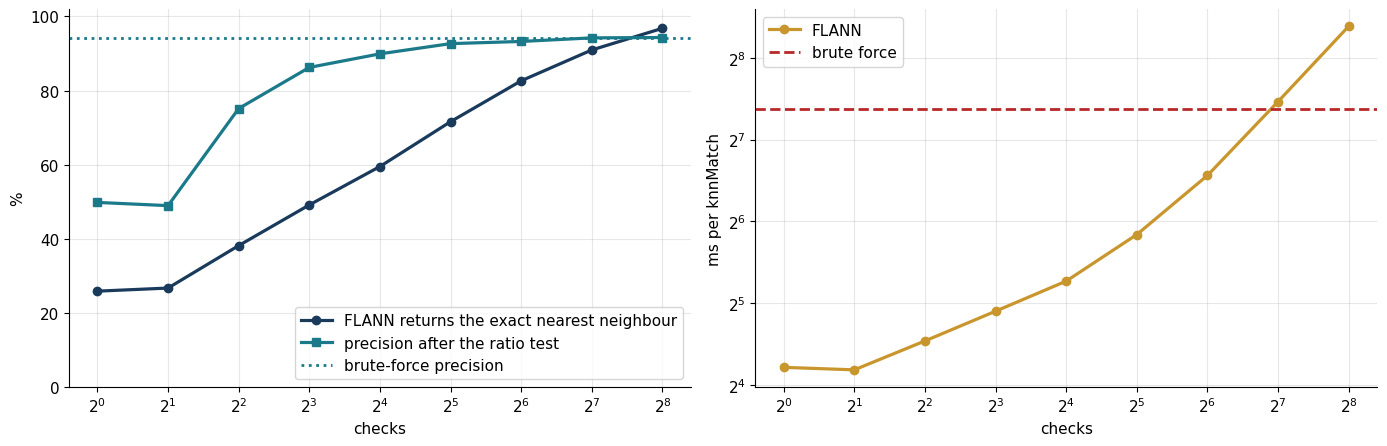

checks     ms  exact NN   kept  precision  correct
     1     19       26%   1313      49.8%      654
     2     18       27%   1322      48.9%      647
     4     23       38%   1082      75.1%      813
     8     30       49%   1010      86.2%      871
    16     39       59%    980      89.9%      881
    32     57       72%    967      92.7%      896
    64     94       83%    962      93.2%      897
   128    177       91%    950      94.2%      895
   256    334       97%    949      94.3%      895
    BF    166      100%    949      94.3%      895


In [15]:
try:
    CHECKS = [1, 2, 4, 8, 16, 32, 64, 128, 256]
    sweep = []
    for c in CHECKS:
        fl = make_flann("kdtree", checks=c)
        knn_c, t_c = best_of(lambda: fl.knnMatch(d1, d2, k=2))
        g = ratio_test(knn_c); ok = is_correct(k1, k2, g, H)
        same_c = np.mean(np.array([p[0].trainIdx for p in knn_c]) == nn_bf)
        sweep.append((c, 1000*t_c, same_c, len(g), ok.mean(), ok.sum(), knn_c))

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
    ax[0].semilogx([s[0] for s in sweep], [100*s[2] for s in sweep], 'o-', color=NAVY, lw=2.3, base=2,
                   label="FLANN returns the exact nearest neighbour")
    ax[0].semilogx([s[0] for s in sweep], [100*s[4] for s in sweep], 's-', color=TEAL, lw=2.3, base=2,
                   label="precision after the ratio test")
    ax[0].axhline(100*ok_bf.mean(), color=TEAL, ls=':', lw=2, label="brute-force precision")
    ax[0].set_xlabel("checks"); ax[0].set_ylabel("%"); ax[0].set_ylim(0, 102)
    ax[0].legend(loc="lower right"); ax[0].grid(alpha=0.3)
    ax[1].loglog([s[0] for s in sweep], [s[1] for s in sweep], 'o-', color=GOLD, lw=2.3, base=2, label="FLANN")
    ax[1].axhline(1000*t_bf, color=RED, ls='--', lw=2, label="brute force")
    ax[1].set_xlabel("checks"); ax[1].set_ylabel("ms per knnMatch"); ax[1].legend(); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f"{'checks':>6}{'ms':>7}{'exact NN':>10}{'kept':>7}{'precision':>11}{'correct':>9}")
    for c, t_c, s_c, n_c, p_c, r_c, _ in sweep:
        print(f"{c:6}{t_c:7.0f}{100*s_c:9.0f}%{n_c:7}{100*p_c:10.1f}%{r_c:9}")
    print(f"{'BF':>6}{1000*t_bf:7.0f}{'100':>9}%{len(good_bf):7}{100*ok_bf.mean():10.1f}%{ok_bf.sum():9}")
except NotImplementedError:
    print("Complete Task 1 first.")

Two things look odd. At **1 check** FLANN keeps *more* matches than brute force, and half
of them are wrong. And at **32 checks** FLANN misses the exact nearest neighbour for
roughly a quarter of the queries, yet its precision is within about two points of
brute force. The next cell looks inside both.


How to read the generated table:

On the left are the examples where the exact nearest neighbour is found. It is split into two groups. 1. Brute-Force kept and got correct 2. everything else (BF kept but got wrong, or BF rejected).

On the right are the examples that FLANN keeps, but it shouldn't have (they are wrong). Again split into two groups: 1. 1st neighbour is the same as BF found and on the right the ratio (d1/d2) is less than the BF ratio. A small BF ratio is going to be kept (clear winner) during thresholding.

In [19]:
try:
    if not sweep:
        raise NameError
    r_bf = np.array([p[0].distance / p[1].distance for p in knn_bf])
    right_bf = is_correct(k1, k2, [p[0] for p in knn_bf], H)
    bf_good = (r_bf < 0.8) & right_bf                   # what brute force keeps, and is right
    print(f"{'checks':>6} | {'exact NN found for:':^31} | {'FLANN keeps, but wrong:':^38}")
    print(f"{'':>6} | {'BF-kept & right':>15} {'everything else':>15} | {'count':>6} {'1st nbr = BF':>13} {'ratio < BF ratio':>17}")
    for c, *_, knn_c in sweep:
        if c not in (1, 8, 32, 128):
            continue
        nn_c = np.array([p[0].trainIdx for p in knn_c])
        r_c = np.array([p[0].distance / p[1].distance for p in knn_c])
        same_c = nn_c == nn_bf
        wrong_kept = (r_c < 0.8) & ~is_correct(k1, k2, [p[0] for p in knn_c], H)
        print(f"{c:6} | {100*same_c[bf_good].mean():14.1f}% {100*same_c[~bf_good].mean():14.1f}% | "
              f"{wrong_kept.sum():6} {100*same_c[wrong_kept].mean():12.0f}% {100*(r_c < r_bf)[wrong_kept].mean():16.0f}%")
except NameError:
    print("Complete Task 1 and run Step 3 first.")

checks |       exact NN found for:       |        FLANN keeps, but wrong:        
       | BF-kept & right everything else |  count  1st nbr = BF  ratio < BF ratio
     1 |           70.5%           11.0% |    659           25%               90%
     8 |           95.9%           33.6% |    139           88%               86%
    32 |           99.4%           62.3% |     71          100%               54%
   128 |           99.9%           88.0% |     55          100%                7%


**Interpreting the above**

In the first row we see that FLANN keeps many bad matches, and only a fraction of those have the 1st neighbour correct (as per BF), the second neighbour is even worse which is why the ratio is less than BF most of the time.

When checks is low FLANN finds lots of the correct matches (the kdtree divisions work ... as evidenced by the left side of the table), but isn't allowed to look at enough potential neighbours to find the 2nd best match. So d2 is inflated and this gives the confidence in d1 such that the ratio test is passed. i.e., FLANN often finds good first matches but needs to search longer to find the second match otherwise the ratio test will keep too many bad matches.

### Step 4 · ORB needs a different index

ORB descriptors are 32 **bytes**, compared with Hamming distance (L7 §8). A kd-tree splits
on one coordinate at a time and measures L2 distance; neither makes sense for bits.
OpenCV refuses outright. Below: the error, then the tempting fix (cast the bytes to
float, which is exactly L7 §8.2's "wrong metric" with a kd-tree on top), then LSH.

In [20]:
try:
    orb = cv2.ORB_create(nfeatures=3000)
    o1k, o1 = orb.detectAndCompute(img, None)
    o2k, o2 = orb.detectAndCompute(img2, mask2)

    try:
        make_flann("kdtree").knnMatch(o1, o2, k=2)
    except cv2.error as e:
        print("kd-tree on uint8 ORB descriptors ->", str(e).strip().splitlines()[0][:110], "...\n")

    rows = {
        "BF, Hamming (L7)":     lambda: cv2.BFMatcher(cv2.NORM_HAMMING).knnMatch(o1, o2, k=2),
        "kd-tree on float(ORB)": lambda: make_flann("kdtree").knnMatch(np.float32(o1), np.float32(o2), k=2),
        "FLANN LSH":            lambda: make_flann("lsh").knnMatch(o1, o2, k=2),
    }
    print(f"{'ORB':24}{'time':>8}{'kept':>7}{'precision':>11}{'correct':>9}{'queries with < 2 nbrs':>23}")
    for name, f in rows.items():
        knn_o, t_o = best_of(f)
        g = ratio_test(knn_o); ok = is_correct(o1k, o2k, g, H)
        short = sum(len(p) < 2 for p in knn_o)
        print(f"{name:24}{1000*t_o:6.0f} ms{len(g):7}{100*ok.mean():10.1f}%{ok.sum():9}{short:23}")
except NotImplementedError:
    print("Complete Task 1 first.")

kd-tree on uint8 ORB descriptors -> OpenCV(5.0.0) /io/opencv/modules/flann/src/miniflann.cpp:336: error: (-210:Unsupported format or combination o ...

ORB                         time   kept  precision  correct  queries with < 2 nbrs
BF, Hamming (L7)           119 ms   1193      96.1%     1147                      0
kd-tree on float(ORB)       61 ms    631      90.5%      571                      0
FLANN LSH                   93 ms   1219      94.4%     1151                      0


> **The `ValueError` you will meet in the wild.** Most tutorials write
> `for m, n in matches:`. LSH can return *fewer than two* neighbours for a query whose
> buckets are nearly empty, and then that line crashes with
> `ValueError: not enough values to unpack`. On this pair every query got two (last
> column), but on a small or unusual image it happens. `ratio_test` above skips such
> queries instead.

### Checkpoint 1

**Q1a.** With 1 check, FLANN *keeps more* matches than brute force, and about half are
wrong. Use the "FLANN keeps, but wrong" columns to explain **how an approximate search
can make the ratio test accept a wrong match.** Is the problem usually the first
neighbour or the second?

*Your answer:* Whenever the count number gets closer to matching the first value of brute force, it tends to show an improvement in overal accuracy as well. The approximate searches FLANN uses are based on some neighbors of neighbors, which can lead to the wrong values accepted or rejected. This shows that the problem leading to a mismatch could potentially reside in the second neighbor rather than the first one.

**Q1b.** At 32 checks FLANN misses the exact nearest neighbour for about a quarter of
all queries, yet loses almost none of the matches brute force keeps. Which queries does
it miss, and why are those the ones a kd-tree finds hardest?

*Your answer:* Most of the queries missed are the ones brute force also did not get, these may be the neighbors that are in the same group at sublevel 32 in a kd-tree. If they are in the same group, FLANN will take one value of the subgroup and flag it as found, then if the subgroup contains another NN value, it will not get considered as the subgroup itself was marked as "NN found" before.

**Q1c.** On this pair of images, is FLANN worth it? Compare the execution time for number of checks and the level of achieved precision. What would you would
accept. What would have to change for FLANN to win by a large margin? (Part 3 tests your
prediction.)

*Your answer:*

**Q1d.** Casting ORB to float "works": no error, hundreds of matches. What exactly is
wrong with it? Give one reason from L7 §8.2 and one about the kd-tree itself.

*Your answer:*

---
## Part 2 — A Real Pair: Two Consecutive 1958 Air Photos  `⏱ ~15 min`

An air survey flies straight lines and fires the camera so that each photo overlaps the
next by about **60%**, so every spot on the ground appears in at least two photos.
Frames **16046-19** and **16046-20** are consecutive photos on flight line 16046, taken
seconds apart in 1958. They are raw scans of the contact prints, reduced to 1000 px tall
(about 3.5 m per pixel); the ink outlines are forestry annotations drawn on the prints.

There is no synthetic warp here, so where does "correct" come from? From a **reference
homography** `H_REF` that maps frame 19 into frame 20. It was fitted on the
full-resolution scans (how: L8, after reading week). Treat it as given; the checkerboard
lets you check it yourself. Relief and lens distortion mean no single 3×3 matrix fits a
real photo pair perfectly, so here a match counts as correct within **5 px** (≈ 18 m).

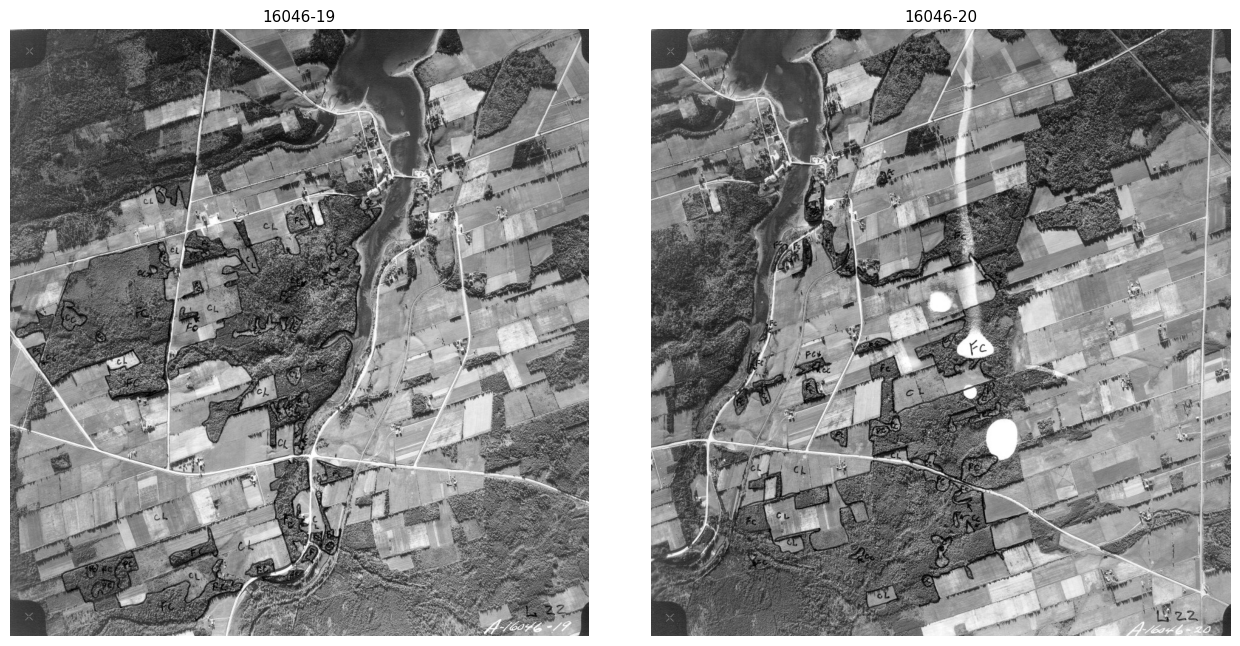

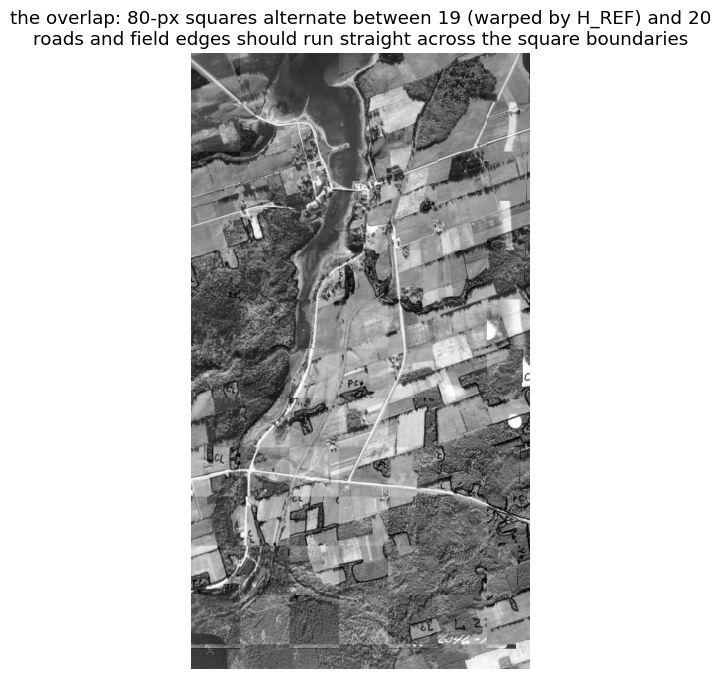

In [21]:
A = cv2.imread("frames/16046-19.jpg", cv2.IMREAD_GRAYSCALE)
B = cv2.imread("frames/16046-20.jpg", cv2.IMREAD_GRAYSCALE)

H_REF = np.array([[ 0.98700935, -0.00873884, -390.04915793],     # frame 19 -> frame 20
                  [ 0.00098735,  1.01974419,  -25.81833349],     # (1000-px frames)
                  [-0.00000007,  0.00002919,    1.        ]])
TOL_REAL = 5   # px

# checkerboard: frame 19 warped into frame 20, alternating 80-px squares where both exist
A_in_B = cv2.warpPerspective(A, H_REF, (B.shape[1], B.shape[0]))
valid = cv2.warpPerspective(np.full_like(A, 255), H_REF, (B.shape[1], B.shape[0])) > 0
yy, xx = np.mgrid[:B.shape[0], :B.shape[1]]
cb = np.where(((yy // 80 + xx // 80) % 2 == 0) & valid, A_in_B, B)
x0 = np.where(valid.any(0))[0].max()

show([A, B], ["16046-19", "16046-20"], figw=13, figh=6.5)
plt.figure(figsize=(8, 8)); plt.imshow(cb[:, :x0], cmap='gray'); plt.axis('off')
plt.title("the overlap: 80-px squares alternate between 19 (warped by H_REF) and 20\n"
          "roads and field edges should run straight across the square boundaries")
plt.show()

**Before you run the next cell:** find the river and the road crossing in both frames.
Which way did the plane fly, and roughly what fraction of frame 19 is also in frame 20?

### Step 1 · Match, and look

SIFT, a kd-tree FLANN, the ratio test at Lowe's 0.8. The first picture is the standard
OpenCV drawing (`cv2.drawMatchesKnn` with a `matchesMask`, as in the OpenCV FLANN
tutorial) for 60 random pairs that passed. **Can you tell which of the lines are wrong?**

11,654 keypoints in 19, 11,239 in 20


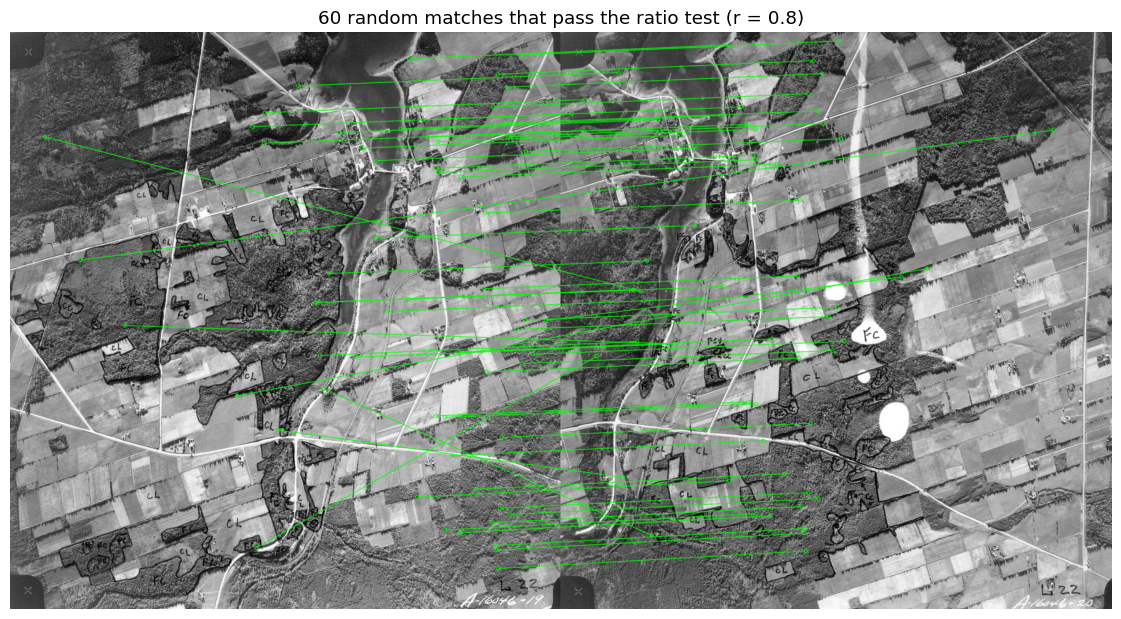

In [22]:
try:
    ka, da = sift.detectAndCompute(A, None)
    kb, db = sift.detectAndCompute(B, None)
    knn_ab = make_flann("kdtree").knnMatch(da, db, k=2)

    ratio_ab = np.array([p[0].distance / p[1].distance for p in knn_ab])
    pa = np.float32([ka[p[0].queryIdx].pt for p in knn_ab])     # every keypoint in 19 ...
    pb = np.float32([kb[p[0].trainIdx].pt for p in knn_ab])     # ... and its nearest neighbour in 20
    right_ab = np.linalg.norm(project(pa, H_REF) - pb, axis=1) < TOL_REAL
    print(f"{len(ka):,} keypoints in 19, {len(kb):,} in 20")

    rng = np.random.default_rng(9)
    passed = np.where(ratio_ab < 0.8)[0]
    pick = set(rng.choice(passed, 60, replace=False).tolist())
    mask_draw = [[1, 0] if i in pick else [0, 0] for i in range(len(knn_ab))]
    vis = cv2.drawMatchesKnn(A, ka, B, kb, knn_ab, None, matchColor=(0, 255, 0),
                             matchesMask=mask_draw, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(15, 7.5)); plt.imshow(vis); plt.axis('off')
    plt.title("60 random matches that pass the ratio test (r = 0.8)"); plt.show()
except NotImplementedError:
    print("Complete Task 1 first.")

### Step 2 · A better picture: where did each point move?

Each match says "this point in 19 moved by $(dx, dy)$ to get to 20". If the camera simply
slid along the flight line, every **correct** match would move by about the same amount,
and wrong matches would land anywhere. So plot the displacements instead of the lines.
Colours use `H_REF`: teal correct, red wrong. Grey dots are nearest neighbours that the
ratio test rejected.

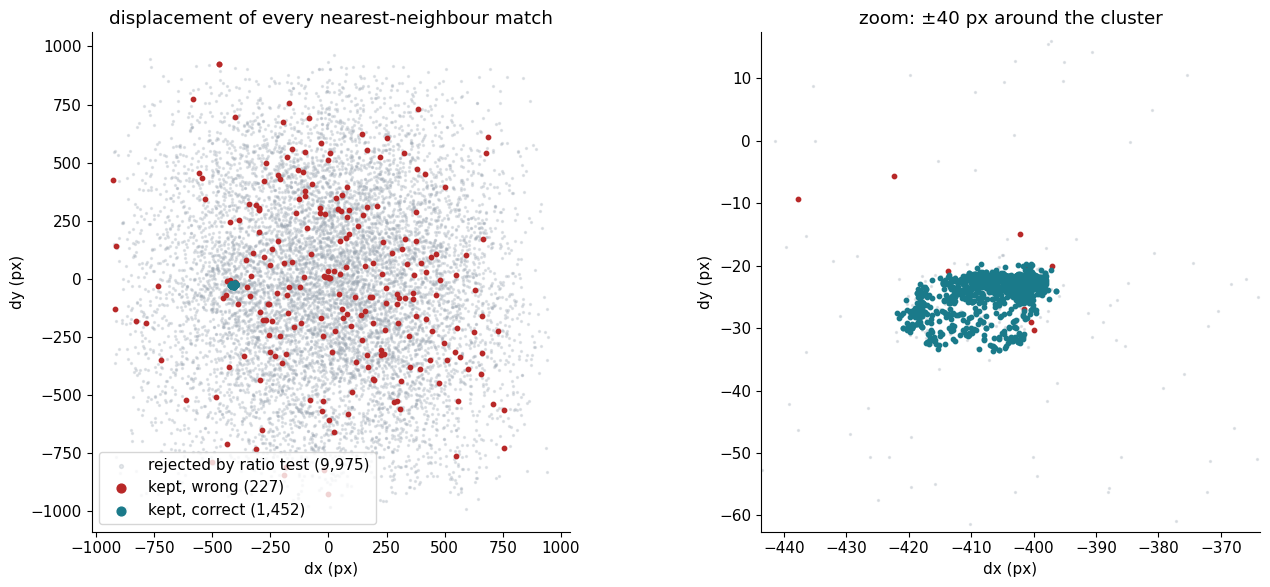

In [23]:
try:
    d_ab = pb - pa
    kept = ratio_ab < 0.8
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    for a, lim in zip(ax, [None, 40]):
        a.scatter(*d_ab[~kept].T, s=2, c=GREY, alpha=0.25, label=f"rejected by ratio test ({(~kept).sum():,})")
        a.scatter(*d_ab[kept & ~right_ab].T, s=10, c=RED, label=f"kept, wrong ({(kept & ~right_ab).sum():,})")
        a.scatter(*d_ab[kept & right_ab].T, s=10, c=TEAL, label=f"kept, correct ({(kept & right_ab).sum():,})")
        a.set_xlabel("dx (px)"); a.set_ylabel("dy (px)"); a.set_aspect('equal')
        if lim:
            c = np.median(d_ab[kept & right_ab], axis=0)
            a.set_xlim(c[0]-lim, c[0]+lim); a.set_ylim(c[1]-lim, c[1]+lim)
            a.set_title(f"zoom: ±{lim} px around the cluster")
        else:
            a.set_title("displacement of every nearest-neighbour match"); a.legend(loc="lower left", markerscale=2)
    plt.tight_layout(); plt.show()
except NameError:
    print("Run Step 1 first.")

### Step 3 · A correctness check without ground truth  (Task 2)

In a real project there is no `H_REF`. But the plot suggests a check that needs none:
**a match is believable if it agrees with what most of the other matches say.** Take the
*median* displacement of the kept matches as "the" shift of the camera, and accept a
match if its own displacement is within `tol` px of it.

**Task 2:** complete `consistent`.

In [26]:
def consistent(pa, pb, tol=20):
    '''
    pa, pb : (N, 2) arrays of matched points in frame 19 and frame 20.
    Returns (shift, ok):
      shift : the median displacement (dx, dy) of all N matches
      ok    : boolean array (N,), True where a match's displacement is within `tol` px of `shift`
    '''
    # ────────────────────────────────────────────────────────────────────────────
    d = pb - pa
    shift = np.median(d, axis=0)
    ok = np.linalg.norm(d - shift, axis=1) < tol
    return (shift, ok)
    # ── YOUR CODE HERE ──────────────────────────────────────────────────────────
    # 1. d = pb - pa
    # 2. shift = np.median(d, axis=0) #(why the median, not the mean?) axis 0 is the rows
    # 3. ok = np.linalg.norm(d - shift, axis=1) < tol # (axis 1 is the columns) .norm converts each dx, dy into its distance from the median (in x and y (same as length or norm of the vector)
    # ────────────────────────────────────────────────────────────────────────────
    raise NotImplementedError("Task 2: return (shift, ok).")

In [27]:
try:
    shift, _ = consistent(pa[ratio_ab < 0.8], pb[ratio_ab < 0.8])
    print(f"camera shift: dx = {shift[0]:.0f} px, dy = {shift[1]:.0f} px   "
          f"-> forward overlap ≈ {100*(1 - abs(shift[0])/A.shape[1]):.0f}% of the frame width\n")

    print(f"{'r':>5}{'kept':>7}{'precision':>11}{'consistent':>12}{'precision of consistent':>25}{'correct ones kept':>19}")
    for r in (0.6, 0.7, 0.8, 0.9, 1.0):
        k = ratio_ab < r
        _, ok = consistent(pa[k], pb[k])
        print(f"{r:5}{k.sum():7,}{100*right_ab[k].mean():10.1f}%{ok.sum():12,}"
              f"{100*right_ab[k][ok].mean():24.1f}%{100*(right_ab[k] & ok).sum()/right_ab[k].sum():18.1f}%")
except NotImplementedError:
    print("Complete Task 2 first.")
except NameError:
    print("Run Steps 1-2 first.")

camera shift: dx = -403 px, dy = -23 px   -> forward overlap ≈ 58% of the frame width

    r   kept  precision  consistent  precision of consistent  correct ones kept
  0.6    980      99.6%         976                   100.0%             100.0%
  0.7  1,261      97.9%       1,236                    99.8%             100.0%
  0.8  1,679      86.5%       1,460                    99.5%             100.0%
  0.9  3,270      48.9%       1,579                    99.1%              97.9%
  1.0 11,654      14.6%          11                     0.0%               0.0%


The same kept matches, drawn as lines and coloured by the consistency check alone
(green consistent, red not), with a sample of 250 so the picture stays readable.

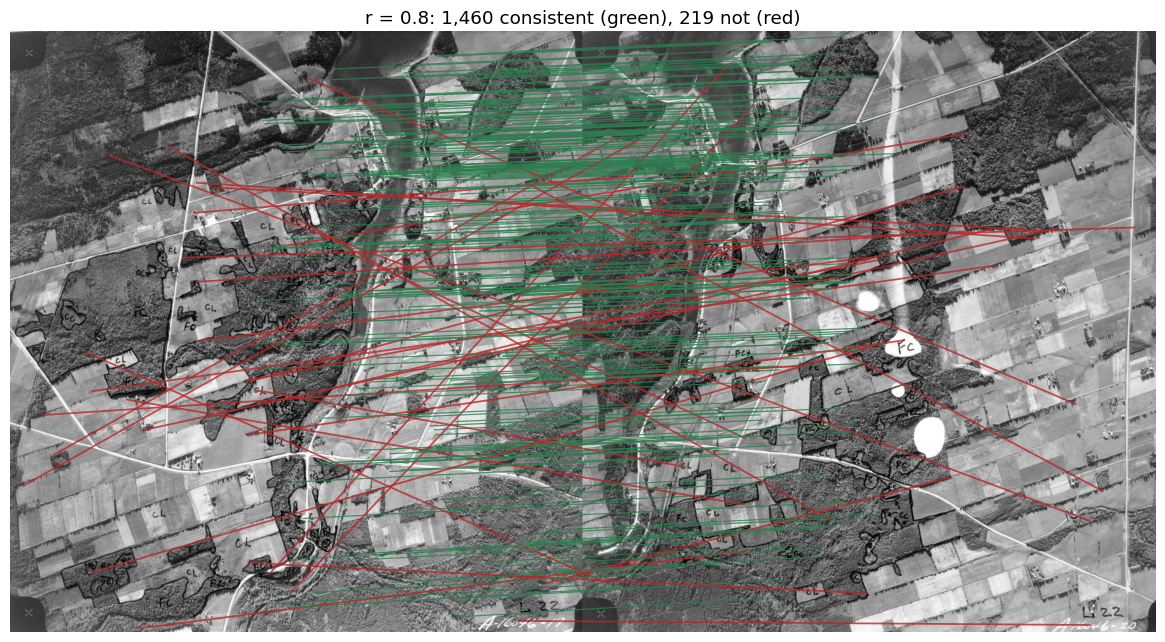

In [28]:
def draw_lines(A, B, pa, pb, good, n=250, seed=0, title=""):
    # Side-by-side images with match lines, green where good is True, red otherwise.
    canvas = np.zeros((max(A.shape[0], B.shape[0]), A.shape[1] + B.shape[1]), np.uint8)
    canvas[:A.shape[0], :A.shape[1]] = A; canvas[:B.shape[0], A.shape[1]:] = B
    idx = np.random.default_rng(seed).choice(len(pa), min(n, len(pa)), replace=False)
    plt.figure(figsize=(15, 7.8)); plt.imshow(canvas, cmap='gray')
    for i in idx:
        plt.plot([pa[i, 0], pb[i, 0] + A.shape[1]], [pa[i, 1], pb[i, 1]],
                 color=GREEN if good[i] else RED, lw=0.9 if good[i] else 1.3, alpha=0.8)
    plt.axis('off'); plt.title(title); plt.show()

try:
    k = ratio_ab < 0.8
    _, ok = consistent(pa[k], pb[k])
    draw_lines(A, B, pa[k], pb[k], ok, title=f"r = 0.8: {ok.sum():,} consistent (green), {(~ok).sum():,} not (red)")
except NotImplementedError:
    print("Complete Task 2 first.")
except NameError:
    print("Run Steps 1-3 first.")

### Checkpoint 2

**Q2a.** What forward overlap did you measure? Why would a survey want *at least* 50%,
and why is 60% the usual choice rather than 50%?

*Your answer:*

**Q2b.** Lowe's 0.8 gave about 95% precision on the L7 pair. What does it give here,
and which `r` would you choose for this pair? Give two differences between the real pair
and the synthetic one that make the real pair harder.

*Your answer:*

**Q2c.** The consistency check knows nothing about `H_REF`, yet agrees with it well.
Which *wrong* matches can it never catch? Which *correct* matches would a smaller `tol`
start to reject, and where in the image would they be? What model would replace "one
median shift" to fix that? (This is where L8 starts.)

*Your answer:*

---
## Part 3 — Which Photo Is This?  `⏱ ~20 min`

The 1958 county mosaic was cut and orthorectified from raw frames like these, and the
raw frames carry no coordinates. The coastal groups need the opposite direction: for a
place on the map, **find the raw photos that show it.**

The query is the 1958 clip you have used since AL2 (a piece of the mosaic). The haystack
is twenty frames: the six consecutive frames 16046-17 to -22, five frames from the
neighbouring flight line (16046-101 to -105), and nine from elsewhere on the Island.

### Step 1 · Describe the haystack, and the query

The frames are about 3.5 m per pixel; the clip is 1.16 m. We shrink the clip by 3 so both
are at about the same scale (the Bonus asks whether that matters). Describing twenty
frames takes 10–30 s.

described 20 frames in 9.6 s: 80,007 descriptors in all
query: 230x230 px, 504 keypoints


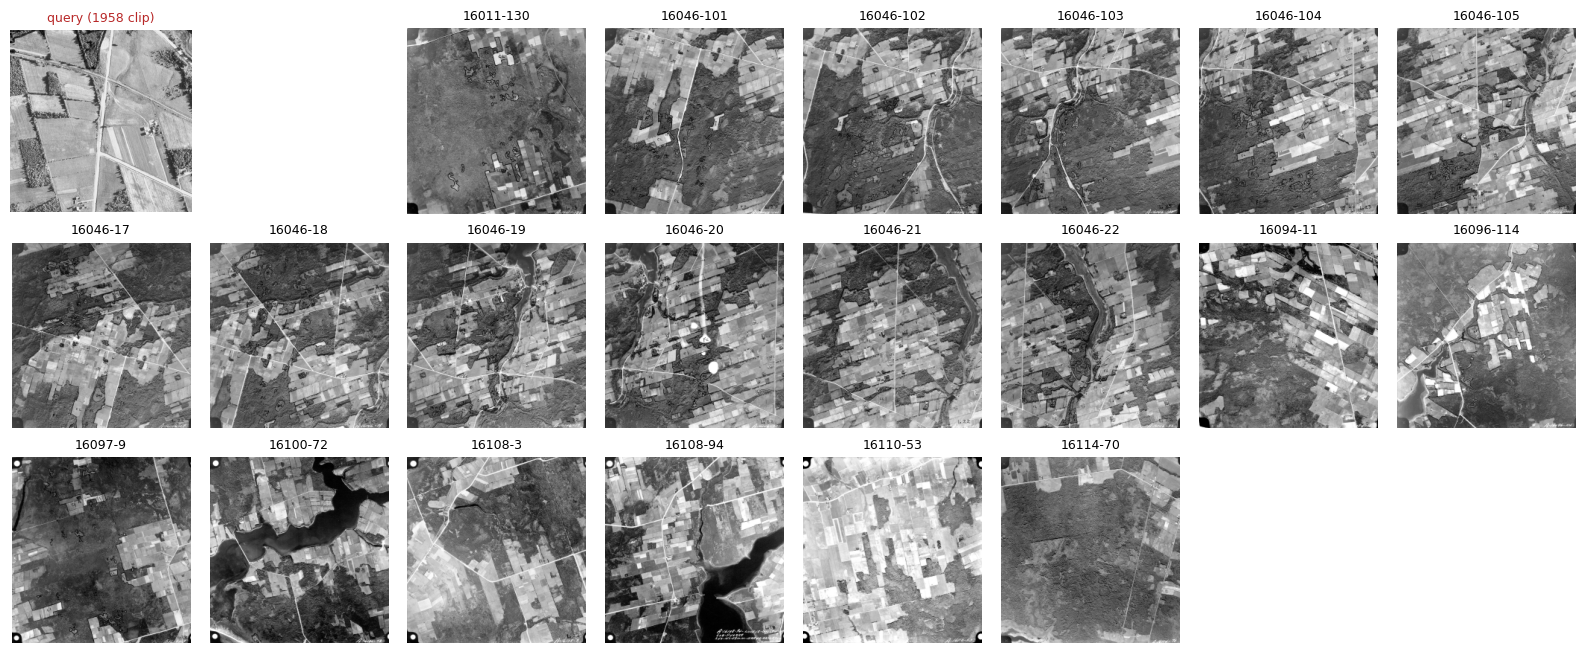

In [29]:
sift_db = cv2.SIFT_create(nfeatures=4000)     # keep the 4,000 strongest per frame
FR, KP, DESC = {}, {}, {}
t0 = time.perf_counter()
for n in NAMES:
    FR[n] = cv2.imread(f"frames/{n}.jpg", cv2.IMREAD_GRAYSCALE)
    KP[n], DESC[n] = sift_db.detectAndCompute(FR[n], None)
print(f"described {len(NAMES)} frames in {time.perf_counter()-t0:.1f} s: "
      f"{sum(len(d) for d in DESC.values()):,} descriptors in all")

QUERY_SCALE = 1/3
clip58 = cv2.imread("pei_1958.png", cv2.IMREAD_GRAYSCALE)
query = cv2.resize(clip58, None, fx=QUERY_SCALE, fy=QUERY_SCALE, interpolation=cv2.INTER_AREA)
kq, dq = sift.detectAndCompute(query, None)
print(f"query: {query.shape[1]}x{query.shape[0]} px, {len(kq)} keypoints")

fig, axes = plt.subplots(3, 8, figsize=(16, 6.6))
for ax in axes.ravel(): ax.axis('off')
axes[0, 0].imshow(clip58, cmap='gray'); axes[0, 0].set_title("query (1958 clip)", fontsize=9, color=RED)
for ax, n in zip(axes.ravel()[2:], NAMES):
    ax.imshow(cv2.resize(FR[n], (240, 250), interpolation=cv2.INTER_AREA), cmap='gray')
    ax.set_title(n, fontsize=9)
plt.tight_layout(); plt.show()

**Before you go on:** from the thumbnails, which frames do you think contain the clip?

### Step 2 · Brute force, one frame at a time

For each frame: `knnMatch` the query against that frame alone, ratio test, count what
survives. The frame with the most votes wins.

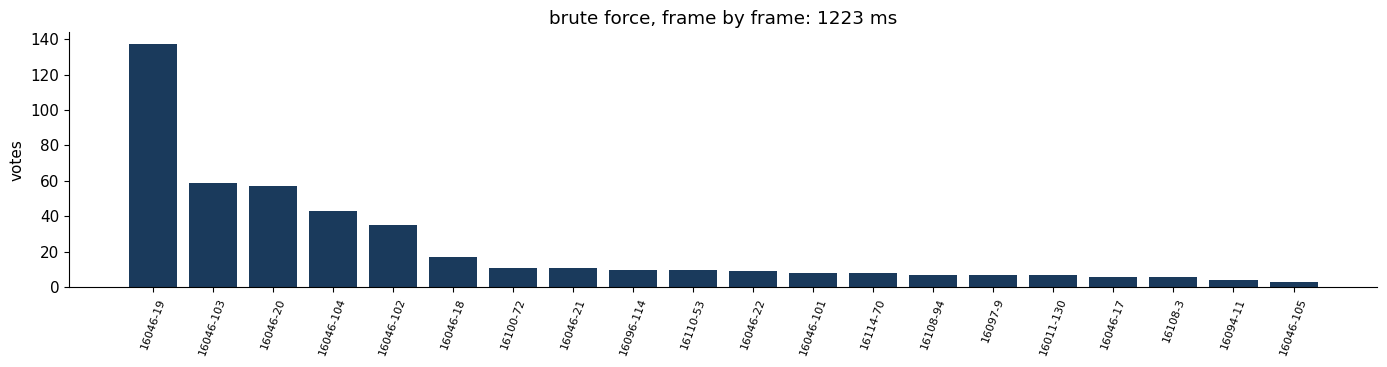

top five: 16046-19 (137), 16046-103 (59), 16046-20 (57), 16046-104 (43), 16046-102 (35)


In [30]:
def bf_votes(names, r=0.8):
    bfm = cv2.BFMatcher(cv2.NORM_L2)
    return np.array([len(ratio_test(bfm.knnMatch(dq, DESC[n], k=2), r)) for n in names])

votes_bf, t_loop = best_of(lambda: bf_votes(NAMES))

def bar_votes(ax, votes, title, colour):
    order = np.argsort(-votes)
    ax.bar(range(len(NAMES)), votes[order], color=colour)
    ax.set_xticks(range(len(NAMES))); ax.set_xticklabels([NAMES[i] for i in order], rotation=70, fontsize=8)
    ax.set_ylabel("votes"); ax.set_title(title)

fig, ax = plt.subplots(figsize=(14, 3.8))
bar_votes(ax, votes_bf, f"brute force, frame by frame: {1000*t_loop:.0f} ms", NAVY)
plt.tight_layout(); plt.show()
print("top five:", ", ".join(f"{NAMES[i]} ({votes_bf[i]})" for i in np.argsort(-votes_bf)[:5]))

### Step 3 · One index for the whole haystack  (Task 3)

Matching against each frame in turn repeats the work twenty times.

A `FlannBasedMatcher` can hold **many** train sets:
- `add()` a list of descriptor arrays,
- `train()` once to build one index over all of them,
- then `knnMatch(dq, k=2)` with no second argument searches everything.

Each returned `DMatch` has an **`imgIdx`**: the position, in the list you added, of the frame the neighbour came from.

Count the surviving matches per `imgIdx` and you have the votes.

**Task 3:** fill in the cell. Time the build and the query separately.

In [ ]:
index, votes_idx, t_build, t_query = None, None, None, None

# ── YOUR CODE HERE ──────────────────────────────────────────────────────────────
# 1. index = make_flann("kdtree")
# 2. index.add([DESC[n] for n in NAMES])
#    time index.train()                                       -> t_build (seconds)
# 3. time knn = index.knnMatch(dq, k=2)                       -> t_query (seconds)
# 4. votes_idx = np.bincount([m.imgIdx for m in ratio_test(knn)], minlength=len(NAMES))
# ────────────────────────────────────────────────────────────────────────────────

In [ ]:
if votes_idx is None:
    print("Complete Task 3 first.")
else:
    fig, ax = plt.subplots(2, 1, figsize=(14, 7.2))
    bar_votes(ax[0], votes_bf, f"brute force, frame by frame: {1000*t_loop:.0f} ms", NAVY)
    bar_votes(ax[1], votes_idx, f"one FLANN index: build {1000*t_build:.0f} ms (once), "
                                f"query {1000*t_query:.0f} ms", GOLD)
    plt.tight_layout(); plt.show()
    print(f"{'frame':10}{'brute force':>12}{'one index':>11}")
    for i in np.argsort(-votes_bf)[:8]:
        print(f"{NAMES[i]:10}{votes_bf[i]:12}{votes_idx[i]:11}")

The index is twenty times faster per query and picks the same winner. But look at the
**runners-up**: frames that brute force scored highly have almost vanished. They did not
stop containing the clip. Think about what the ratio test compares, and what the second
nearest neighbour is now that all twenty frames sit in one index. Then answer **Q3a**
before reading on.

### Step 4 · A ratio test per frame

The fix keeps the single index but asks the ratio question **within each frame**: is this
frame's best match clearly better than *this frame's* second best? Ask the index for
more neighbours (`k=10`) and group them by `imgIdx`. If a frame has only one of the ten,
its second best is somewhere further than the 10th neighbour, so the 10th distance is a
safe stand-in.

In [ ]:
def per_frame_votes(knn, n_frames, r=0.8):
    votes = np.zeros(n_frames, int)
    for nbrs in knn:                          # the K nearest, closest first, from any frame
        bound = nbrs[-1].distance             # anything not in the list is at least this far
        by_frame = {}
        for m in nbrs:
            by_frame.setdefault(m.imgIdx, []).append(m.distance)
        for f, d in by_frame.items():
            second = d[1] if len(d) > 1 else bound
            if d[0] < r * second:
                votes[f] += 1
    return votes

if index is None:
    print("Complete Task 3 first.")
else:
    knn10, t_q10 = best_of(lambda: index.knnMatch(dq, k=10))
    votes_pf = per_frame_votes(knn10, len(NAMES))
    fig, ax = plt.subplots(figsize=(14, 3.8))
    bar_votes(ax, votes_pf, f"one FLANN index, ratio test per frame (k = 10): query {1000*t_q10:.0f} ms", TEAL)
    plt.tight_layout(); plt.show()
    print(f"{'frame':10}{'brute force':>12}{'one index':>11}{'per frame':>11}")
    for i in np.argsort(-votes_pf)[:8]:
        print(f"{NAMES[i]:10}{votes_bf[i]:12}{votes_idx[i]:11}{votes_pf[i]:11}")

### Step 5 · How does each approach scale?

The full 1958 collection is **2,322 frames**. Time both approaches on the first 1, 2, 5,
10 and 20 frames, and extrapolate.

In [ ]:
if index is None:
    print("Complete Task 3 first.")
else:
    sizes, t_bf_n, t_build_n, t_q_n = [1, 2, 5, 10, 20], [], [], []
    for n in sizes:
        sub = NAMES[:n]
        t_bf_n.append(best_of(lambda: bf_votes(sub))[1])
        fl = make_flann("kdtree"); fl.add([DESC[x] for x in sub])
        t_build_n.append(best_of(lambda: fl.train(), 1)[1])
        t_q_n.append(best_of(lambda: fl.knnMatch(dq, k=10))[1])

    plt.figure(figsize=(8, 4.4))
    plt.plot(sizes, 1000*np.array(t_bf_n), 'o-', color=NAVY, lw=2.3, label="brute force, frame by frame (per query)")
    plt.plot(sizes, 1000*np.array(t_q_n), 's-', color=TEAL, lw=2.3, label="one FLANN index (per query)")
    plt.plot(sizes, 1000*np.array(t_build_n), '^--', color=GOLD, lw=2, label="building that index (once)")
    plt.xlabel("frames in the haystack"); plt.ylabel("ms"); plt.grid(alpha=0.3); plt.legend()
    plt.tight_layout(); plt.show()

    per_bf, per_build = t_bf_n[-1] / 20, t_build_n[-1] / 20
    mem = 2322 * 4000 * 128 * 4 / 1e9
    print(f"brute force:  {1000*per_bf:.0f} ms per frame per query  ->  ~{2322*per_bf:.0f} s per query for 2,322 frames")
    print(f"FLANN build:  {1000*per_build:.0f} ms per frame, once     ->  ~{2322*per_build:.0f} s for 2,322 frames")
    print(f"FLANN query:  {1000*t_q_n[0]:.0f} ms with 1 frame, {1000*t_q_n[-1]:.0f} ms with 20")
    print(f"memory for 2,322 x 4,000 float32 SIFT descriptors: {mem:.1f} GB (Colab gives you about 12)")

### Checkpoint 3

**Q3a.** Why does putting all twenty frames in one index wipe out most of the
runners-up? Why does 16046-19 survive when 16046-20, which also contains the clip, does
not? *(Hint: the clip was cut from a mosaic. Which photo was the mosaic made from at this
spot?)*

*Your answer:*

**Q3b.** In `per_frame_votes`, why is the distance of the 10th neighbour a *safe*
stand-in for a frame's missing second neighbour? What would go wrong if `k` were 2?

*Your answer:*

**Q3c.** Using Step 5, estimate the time to search all 2,322 frames with brute force,
and with one index. What stops you building one index over everything, and what would you
do instead?

*Your answer:*

**Q3d.** Brute force and the per-frame index agree. Name **five** frames that contain
the clip. The votes say *which* frames; what do they **not** tell you yet that the coastal
groups need?

*Your answer:*

---
## ★ Bonus — B1 · Does the query's resolution matter?

SIFT is scale invariant, so why shrink the clip by 3 in Step 1? Re-run the search with
the clip at full resolution (1.16 m/px) and at 1/2, and compare the keypoint count, the
time, and how clearly the five true frames stand out from the best of the rest.

In [ ]:
TRUE = {"16046-19", "16046-20", "16046-102", "16046-103", "16046-104"}   # from Q3d
true_i = [NAMES.index(n) for n in TRUE]
other_i = [i for i in range(len(NAMES)) if NAMES[i] not in TRUE]

print(f"{'scale':>6}{'query kps':>11}{'BF loop':>10}{'weakest true':>14}{'best other':>12}")
for s in (1.0, 1/2, 1/3):
    q = cv2.resize(clip58, None, fx=s, fy=s, interpolation=cv2.INTER_AREA) if s < 1 else clip58
    kq_s, dq_s = sift.detectAndCompute(q, None)
    bfm = cv2.BFMatcher(cv2.NORM_L2)
    t0 = time.perf_counter()
    v = np.array([len(ratio_test(bfm.knnMatch(dq_s, DESC[n], k=2))) for n in NAMES])
    t_s = time.perf_counter() - t0
    print(f"{s:6.2f}{len(kq_s):11,}{1000*t_s:8.0f} ms{v[true_i].min():14}{v[other_i].max():12}")

**B1.** What happens at full resolution, and why? Which keypoints in the
full-resolution clip have no possible partner in a 3.5 m/px frame?

*Your answer:*

---
## Reflection — End of Lab

**R1.** Today you judged matches three ways: a warp you built yourself, a reference
homography someone else fitted, and agreement with the other matches. Which of these will
you actually have in your project, and what does that mean for how you choose `r`?

*Your answer:*

**R2.** Give one situation where you would choose brute force over FLANN, and one
where FLANN is the only practical choice.

*Your answer:*

**R3.** Part 3 showed the ratio test failing silently when the haystack contains the
same ground twice. Where could the same thing happen in your project's data (for example
overlapping tiles, repeated years of the same block, or the 1950 obliques)?

*Your answer:*